# 📉 Prédiction du Churn Client — Telco

**Projet Data Science / Business Intelligence**

Ce notebook analyse les données clients d'un opérateur télécom afin de :
1. Identifier les facteurs de départ (churn).
2. Prédire les clients à risque élevé.
3. Caractériser les clients fidèles.
4. Segmenter les profils à risque.
5. Proposer des actions de rétention.

**Stack :** Python · Pandas · NumPy · Matplotlib · Seaborn · Scikit-learn · XGBoost · imbalanced-learn

---

## 1. Imports & configuration

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                             roc_curve, accuracy_score, precision_score, recall_score, f1_score)
import joblib

sns.set_theme(style="whitegrid", palette="Set2")
RANDOM_STATE = 42
pd.set_option("display.max_columns", 50)

## 2. Compréhension & chargement des données

Le dataset **Telco Customer Churn** (IBM) contient **7 043 clients** et 21 variables :
informations démographiques, services souscrits, contrat, facturation, et la cible `Churn`.

In [2]:
df = pd.read_csv("../data/raw/Telco-Customer-Churn.csv")
print("Dimensions :", df.shape)
df.head()

Dimensions : (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## 3. Nettoyage & préparation

Points d'attention :
- `TotalCharges` est stockée en texte et contient des espaces (clients à `tenure = 0`).
- `SeniorCitizen` est codée 0/1 → on la rend lisible.
- On crée la cible binaire `ChurnFlag` (0 = fidèle, 1 = churn).

In [4]:
# Valeurs manquantes & doublons
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print("TotalCharges manquants :", df["TotalCharges"].isna().sum())
print("Doublons :", df.duplicated().sum())

df["TotalCharges"] = df["TotalCharges"].fillna(0.0)
df["SeniorCitizen"] = df["SeniorCitizen"].map({0: "No", 1: "Yes"})
df["ChurnFlag"] = (df["Churn"] == "Yes").astype(int)

TotalCharges manquants : 11
Doublons : 0


### Feature engineering — variables métier dérivées

In [5]:
SERVICE_COLS = ["OnlineSecurity", "OnlineBackup", "DeviceProtection",
                "TechSupport", "StreamingTV", "StreamingMovies"]

df["TenureGroup"] = pd.cut(df["tenure"], bins=[-1, 12, 24, 48, 60, np.inf],
                           labels=["0-12", "13-24", "25-48", "49-60", "60+"])
df["NumServices"] = (df[SERVICE_COLS] == "Yes").sum(axis=1)
df["AvgChargesPerMonth"] = np.where(df["tenure"] > 0, df["TotalCharges"] / df["tenure"], df["MonthlyCharges"])
df["IsNewCustomer"] = (df["tenure"] <= 6).astype(int)
df["IsMonthToMonth"] = (df["Contract"] == "Month-to-month").astype(int)
df["IsElectronicCheck"] = (df["PaymentMethod"] == "Electronic check").astype(int)
df[["tenure", "TenureGroup", "NumServices", "AvgChargesPerMonth"]].head()

,tenure,TenureGroup,NumServices,AvgChargesPerMonth
0,1,0-12,1,29.850000
1,34,25-48,2,55.573529
2,2,0-12,2,54.075000
3,45,25-48,3,40.905556
4,2,0-12,0,75.825000


## 4. Analyse exploratoire (EDA)

### 4.1 Répartition de la cible

{'No': 0.735, 'Yes': 0.265}

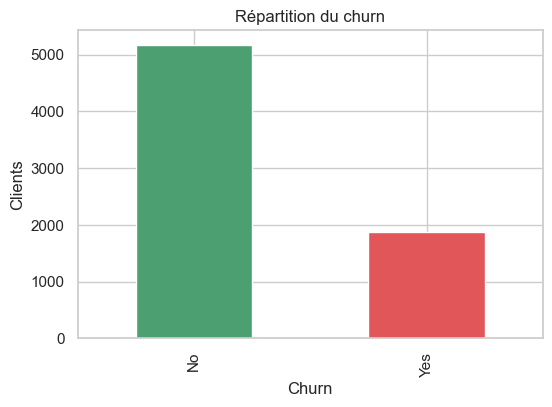

In [6]:
ax = df["Churn"].value_counts().plot(kind="bar", color=["#4C9F70", "#E15759"], figsize=(6,4))
ax.set_title("Répartition du churn"); ax.set_ylabel("Clients")
print(df["Churn"].value_counts(normalize=True).round(3).to_dict())
plt.show()

**~26,5 % des clients ont churné** → classes déséquilibrées (on appliquera SMOTE).

### 4.2 Churn par type de contrat

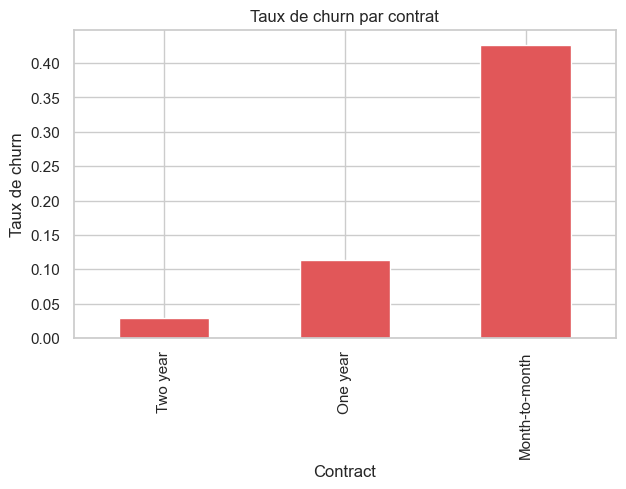

Contract
Two year          0.028
One year          0.113
Month-to-month    0.427
Name: Yes, dtype: float64

In [7]:
ct = pd.crosstab(df["Contract"], df["Churn"], normalize="index")["Yes"].sort_values()
ct.plot(kind="bar", color="#E15759", figsize=(7,4), title="Taux de churn par contrat")
plt.ylabel("Taux de churn"); plt.show()
ct.round(3)

Les contrats **Month-to-month** churnent massivement (~43 %) vs ~3 % pour les contrats 2 ans.

### 4.3 Churn par ancienneté

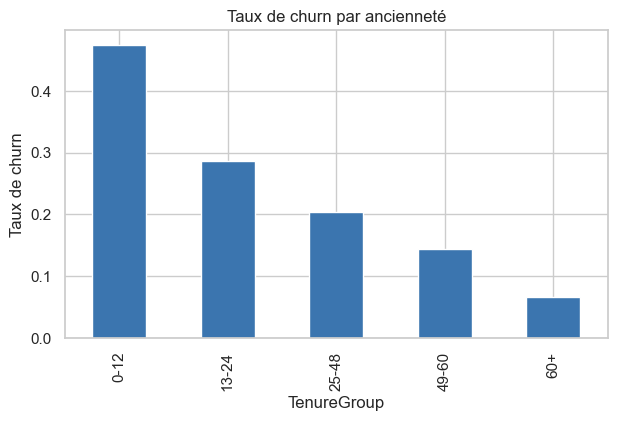

In [8]:
ct = pd.crosstab(df["TenureGroup"], df["Churn"], normalize="index")["Yes"]
ct.plot(kind="bar", color="#3B75AF", figsize=(7,4), title="Taux de churn par ancienneté")
plt.ylabel("Taux de churn"); plt.show()

Le churn est concentré sur les **nouveaux clients (0-12 mois)** puis décroît fortement.

### 4.4 Coût mensuel & méthode de paiement

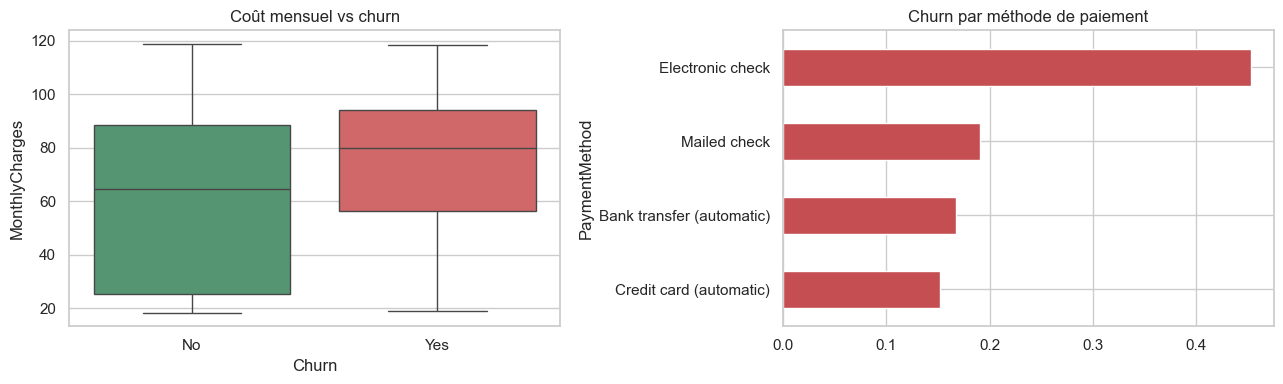

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.boxplot(data=df, x="Churn", y="MonthlyCharges", palette=["#4C9F70","#E15759"], ax=axes[0])
axes[0].set_title("Coût mensuel vs churn")
ct = pd.crosstab(df["PaymentMethod"], df["Churn"], normalize="index")["Yes"].sort_values()
ct.plot(kind="barh", color="#C44E52", ax=axes[1], title="Churn par méthode de paiement")
plt.tight_layout(); plt.show()

Les clients qui churnent paient **plus cher** et utilisent surtout le **chèque électronique** (~45 %).

### 4.5 Heatmap de corrélation

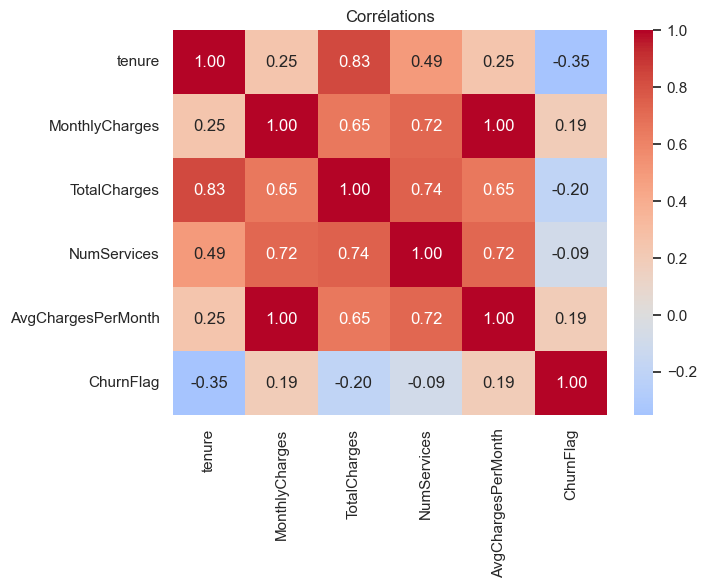

In [10]:
num = df[["tenure", "MonthlyCharges", "TotalCharges", "NumServices", "AvgChargesPerMonth", "ChurnFlag"]]
plt.figure(figsize=(7,5))
sns.heatmap(num.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Corrélations"); plt.show()

## 5. Modélisation

### 5.1 Préparation X / y + préprocessing

In [11]:
DROP = ["customerID", "Churn", "ChurnFlag"]
X = df.drop(columns=DROP)
y = df["ChurnFlag"]

num_cols = X.select_dtypes(include=["int64", "float64", "int32"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)
print("Train:", X_train.shape, "| Test:", X_test.shape)

Train: (5634, 25) | Test: (1409, 25)


### 5.2 Comparaison de 6 modèles (validation croisée + SMOTE)

SMOTE est appliqué **à l'intérieur** de chaque fold pour éviter toute fuite de données.

In [12]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(max_depth=6, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
    "XGBoost": XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=4,
                             subsample=0.9, colsample_bytree=0.9, eval_metric="logloss",
                             random_state=RANDOM_STATE, n_jobs=-1),
    "KNN": KNeighborsClassifier(n_neighbors=15),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
rows = []
for name, model in models.items():
    pipe = ImbPipeline([("prep", preprocessor),
                        ("smote", SMOTE(random_state=RANDOM_STATE)),
                        ("clf", model)])
    auc = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)
    f1  = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="f1", n_jobs=-1)
    rows.append({"Modèle": name, "ROC_AUC": auc.mean(), "F1": f1.mean()})
results = pd.DataFrame(rows).sort_values("ROC_AUC", ascending=False).reset_index(drop=True)
results

,Modèle,ROC_AUC,F1
0,Gradient Boosting,0.845553,0.625906
1,Logistic Regression,0.845126,0.631636
2,XGBoost,0.843817,0.617740
3,Random Forest,0.823755,0.584839
4,Decision Tree,0.816347,0.604429
5,KNN,0.813287,0.596212


### 5.3 Optimisation du meilleur modèle (Gradient Boosting)

In [13]:
best_pipe = ImbPipeline([("prep", preprocessor),
                         ("smote", SMOTE(random_state=RANDOM_STATE)),
                         ("clf", GradientBoostingClassifier(random_state=RANDOM_STATE))])
grid = {"clf__n_estimators": [150, 300],
        "clf__learning_rate": [0.05, 0.1],
        "clf__max_depth": [2, 3]}
search = GridSearchCV(best_pipe, grid, scoring="roc_auc", cv=cv, n_jobs=-1)
search.fit(X_train, y_train)
print("Meilleurs paramètres :", search.best_params_)
print("AUC CV :", round(search.best_score_, 4))
best_model = search.best_estimator_

  File "C:\Users\sall1\AppData\Local\Programs\Python\Python38\lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
  File "C:\Users\sall1\AppData\Local\Programs\Python\Python38\lib\subprocess.py", line 493, in run
    with Popen(*popenargs, **kwargs) as process:
  File "C:\Users\sall1\AppData\Local\Programs\Python\Python38\lib\subprocess.py", line 858, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\sall1\AppData\Local\Programs\Python\Python38\lib\subprocess.py", line 1311, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,


Meilleurs paramètres : {'clf__learning_rate': 0.05, 'clf__max_depth': 2, 'clf__n_estimators': 300}
AUC CV : 0.8461


## 6. Évaluation sur le jeu de test

              precision    recall  f1-score   support

      Fidèle       0.88      0.81      0.84      1035
       Churn       0.56      0.69      0.62       374

    accuracy                           0.77      1409
   macro avg       0.72      0.75      0.73      1409
weighted avg       0.79      0.77      0.78      1409

ROC-AUC : 0.8438


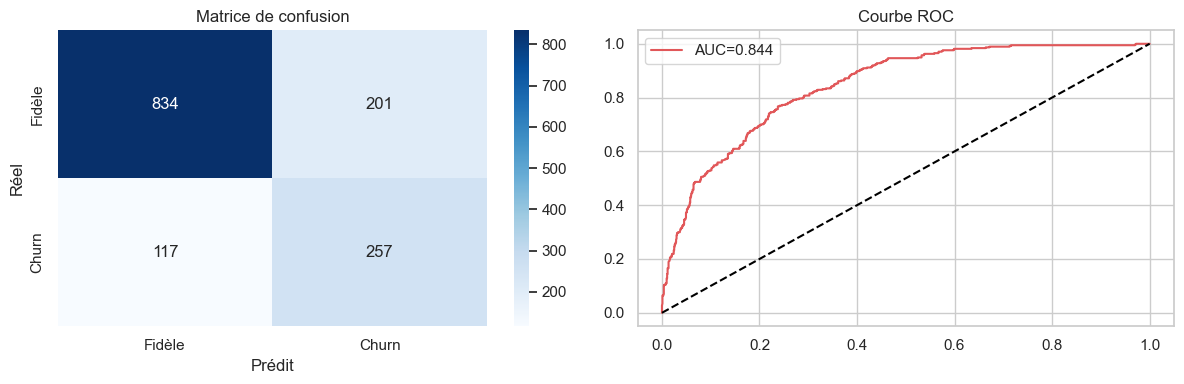

In [14]:
proba = best_model.predict_proba(X_test)[:, 1]
pred = (proba >= 0.5).astype(int)

print(classification_report(y_test, pred, target_names=["Fidèle", "Churn"]))
print("ROC-AUC :", round(roc_auc_score(y_test, proba), 4))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
cm = confusion_matrix(y_test, pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["Fidèle","Churn"], yticklabels=["Fidèle","Churn"])
axes[0].set_title("Matrice de confusion"); axes[0].set_xlabel("Prédit"); axes[0].set_ylabel("Réel")
fpr, tpr, _ = roc_curve(y_test, proba)
axes[1].plot(fpr, tpr, color="#E15759", label=f"AUC={roc_auc_score(y_test, proba):.3f}")
axes[1].plot([0,1],[0,1],"k--"); axes[1].set_title("Courbe ROC"); axes[1].legend()
plt.tight_layout(); plt.show()

## 7. Importance des variables

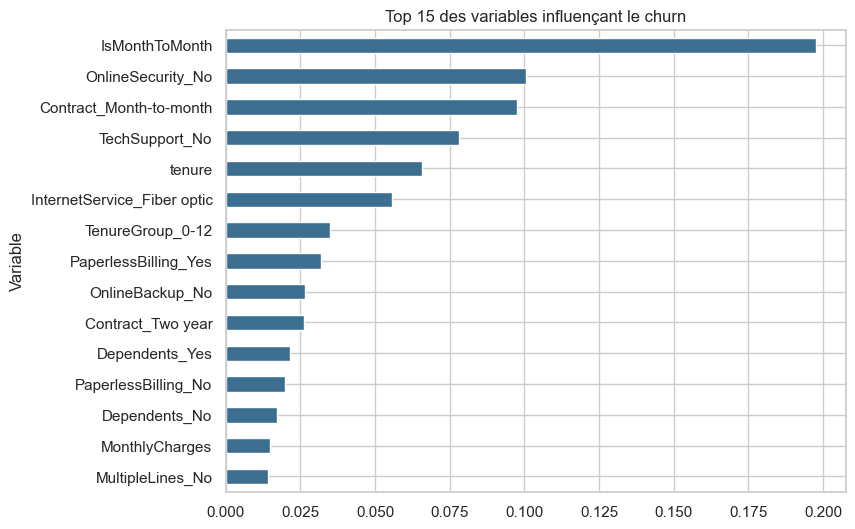

,Variable,Importance
0,IsMonthToMonth,0.197752
1,OnlineSecurity_No,0.100390
2,Contract_Month-to-month,0.097405
3,TechSupport_No,0.078135
4,tenure,0.065819
5,InternetService_Fiber optic,0.055581
6,TenureGroup_0-12,0.034890
7,PaperlessBilling_Yes,0.031899
8,OnlineBackup_No,0.026420
9,Contract_Two year,0.026283


In [15]:
prep = best_model.named_steps["prep"]
clf = best_model.named_steps["clf"]
feat_names = num_cols + list(prep.named_transformers_["cat"].get_feature_names_out(cat_cols))
fi = (pd.DataFrame({"Variable": feat_names, "Importance": clf.feature_importances_})
      .sort_values("Importance", ascending=False).reset_index(drop=True))

fi.head(15).iloc[::-1].plot(kind="barh", x="Variable", y="Importance",
                            figsize=(8,6), legend=False, color="#3B6E8F")
plt.title("Top 15 des variables influençant le churn"); plt.show()
fi.head(10)

**Facteurs dominants :** contrat *Month-to-month*, absence de *OnlineSecurity* / *TechSupport*,
faible ancienneté (`tenure`), fibre optique, facturation dématérialisée.

## 8. Sauvegarde du modèle & scoring des clients (export Power BI)

In [16]:
joblib.dump(best_model, "../models/best_churn_model.pkl")

scored = df.copy()
scored["ChurnProbability"] = best_model.predict_proba(X)[:, 1].round(4)
scored["RiskSegment"] = pd.cut(scored["ChurnProbability"], bins=[-0.01, 0.30, 0.60, 1.01],
                               labels=["Faible", "Moyen", "Élevé"])
scored["RevenueAtRisk"] = np.where(scored["RiskSegment"] == "Élevé", scored["MonthlyCharges"]*12, 0)
scored.to_csv("../powerbi/churn_scored_customers.csv", index=False)

print("Clients à risque élevé :", (scored["RiskSegment"] == "Élevé").sum())
print("Revenu annuel à risque : {:,.0f} $".format(scored["RevenueAtRisk"].sum()))
scored[["customerID","tenure","Contract","MonthlyCharges","ChurnProbability","RiskSegment"]].head()

Clients à risque élevé : 1662
Revenu annuel à risque : 1,514,524 $


,customerID,tenure,Contract,MonthlyCharges,ChurnProbability,RiskSegment
0,7590-VHVEG,1,Month-to-month,29.85,0.7587,Élevé
1,5575-GNVDE,34,One year,56.95,0.0542,Faible
2,3668-QPYBK,2,Month-to-month,53.85,0.4657,Moyen
3,7795-CFOCW,45,One year,42.30,0.0539,Faible
4,9237-HQITU,2,Month-to-month,70.70,0.8288,Élevé


## 9. Conclusions & plan d'actions

**Modèle retenu : Gradient Boosting** — ROC-AUC ≈ 0,84, recall churn ≈ 0,69.

**Profils à risque** : nouveaux clients, contrat sans engagement, sans services de sécurité/support,
paiement par chèque électronique, factures élevées en fibre optique.

**Actions de rétention recommandées :**
1. Inciter au passage en contrat 1 ou 2 ans (remise de fidélité).
2. Offrir OnlineSecurity / TechSupport aux clients fibre à risque.
3. Accompagner les nouveaux clients (onboarding) sur les 12 premiers mois.
4. Migrer les paiements chèque électronique vers prélèvement automatique.
5. Déclencher des alertes automatiques dès qu'un client dépasse un score de risque de 0,60.